In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
import os
from scripts.prepare_datasets import copy_directory_structure, get_valid_paths
from scripts.preprocessing import scale_range, histogram_equalization

# Setting up the environment and file folders

In [2]:
# --- Main Directory: contains all folders/files
root = "S:/CheXpert/"
# --- This is the original root listed on the csv file paths
old_root = "CheXpert-v1.0/train/"
old_test_root = "test/"

# --- Input directory variables
# The training set will be from a sample of 80% of instances from batch 2 and 3
# The validation set will be from the other 20% of instances from batch 2 and 3
# The test set will be batch 4
#
# The valid rad (radiologist) and test rad sets are not primarily used, but will serve as how our model performs
# against real human annotations
source_train_root1 = f"{root}raw_data/CheXpert-v1.0 batch 2 (train 1)/"
source_train_root2 = f"{root}raw_data/CheXpert-v1.0 batch 3 (train 2)/"
source_train_root3 = f"{root}raw_data/CheXpert-v1.0 batch 4 (train 3)/"
source_valid_rad_root = f"{root}raw_data/CheXpert-v1.0 batch 1 (validate & csv)/valid/"
source_test_rad_root = f"{root}raw_data/test/"
#
labels = f"{root}raw_data/train_cheXbert.csv"
valid_rad_labels = f"{root}raw_data/CheXpert-v1.0 batch 1 (validate & csv)/valid.csv"
test_rad_labels = f"{root}raw_data/test_labels.csv"

# --- Output directory variables
train_valid_root = f"{root}train_valid/"
test_root = f"{root}test/"
valid_rad_root = f"{root}valid_rad/" 
test_rad_root = f"{root}test_rad/"

# --- Image sizes
dims = [224, 384, 512]

In [3]:
### --- Create new directories (only run this if necessary)
# This will copy the folder structure from the source roots to the specified new roots

# copy_directory_structure(source_train_root1, train_valid)
# copy_directory_structure(source_train_root2, train_valid)
# copy_directory_structure(source_train_root3, test_root)
# copy_directory_structure(source_valid_root, valid_rad_root)
# copy_directory_structure(source_test_root, test_rad_root)

### Change the sample fraction to use only a subset of the training df

In [4]:
train_sample_frac = 1

In [5]:
# --- Load the training/validation csvs
df = pd.read_csv(labels)
# if train_sample_frac < 1:
#     train_df = train_df.sample(frac=train_sample_frac)
valid_rad_df = pd.read_csv(valid_rad_labels)
test_rad_df = pd.read_csv(test_rad_labels)

#

print(f"# rows in df: {len(df)}")
print(f"# rows in valid_rad_df: {len(valid_rad_df)}")
print(f"# rows in test_rad_df: {len(test_rad_df)}")

# rows in df: 223414
# rows in valid_rad_df: 234
# rows in test_rad_df: 668


In [6]:
# --- Split the df into the corresponding train/valid/test sets

# train and valid sets
train_df1 = df.copy()
# Loop through the directories and get paths that exist
valid_train_paths1 = get_valid_paths(source_train_root1)
# Extract the file paths from the old_root
train_df1["floating_file_path"] = train_df1["Path"].str[len(old_root):]
# Add new file paths
train_df1["source_file_path"] = source_train_root1 + train_df1["floating_file_path"]
for dim in dims:
    dim, col1, col2 = str(dim), f"base{dim}_file_path", f"base{dim}_file_path2"
    train_df1[col1] = train_valid_root + train_df1["floating_file_path"].str[:-4] + f"_{dim}.jpg"
    train_df1[col2] = train_df1[col1].str[:-4] + "_usm.jpg"
# Filter the dfs for only valid paths from the source
train_df1 = train_df1[train_df1["source_file_path"].isin(valid_train_paths1)]

train_df2 = df.copy()
# Loop through the directories and get paths that exist
valid_train_paths2 = get_valid_paths(source_train_root2)
# Extract the file paths from the old_root
train_df2["floating_file_path"] = train_df2["Path"].str[len(old_root):]
# Add new file paths
train_df2["source_file_path"] = source_train_root2 + train_df2["floating_file_path"]
for dim in dims:
    dim, col1, col2 = str(dim), f"base{dim}_file_path", f"base{dim}_file_path2"
    train_df2[col1] = train_valid_root + train_df2["floating_file_path"].str[:-4] + f"_{dim}.jpg"
    train_df2[col2] = train_df2[col1].str[:-4] + "_usm.jpg"
# Filter the dfs for only valid paths from the source
train_df2 = train_df2[train_df2["source_file_path"].isin(valid_train_paths2)]

### Combine the train_dfs
train_df0 = pd.concat([train_df1, train_df2], axis=0)
if train_sample_frac < 1:
    train_df0 = train_df0.sample(frac=train_sample_frac)

### Split into corresponding train/validation sets
train_df, valid_df = train_test_split(train_df0, test_size=0.2)
train_df_full = train_df0.copy()

print(f"# rows in train_df: {len(train_df)}")
print(f"# rows in valid_df: {len(valid_df)}")
print(f"# rows in train_df_full: {len(train_df_full)}")

# rows in train_df: 145949
# rows in valid_df: 36488
# rows in train_df_full: 182437


In [7]:
# test set
test_df = df.copy()
# Loop through the directories and get paths that exist
valid_train_paths3 = get_valid_paths(source_train_root3)
# Extract the file paths from the old_root
test_df["floating_file_path"] = test_df["Path"].str[len(old_root):]
# Add new file paths
test_df["source_file_path"] = source_train_root3 + test_df["floating_file_path"]
for dim in dims:
    dim, col1, col2 = str(dim), f"base{dim}_file_path", f"base{dim}_file_path2"
    test_df[col1] = test_root + test_df["floating_file_path"].str[:-4] + f"_{dim}.jpg"
    test_df[col2] = test_df[col1].str[:-4] + "_usm.jpg"
# Filter the dfs for only valid paths from the source
test_df = test_df[test_df["source_file_path"].isin(valid_train_paths3)]

print(f"# rows in test_df: {len(test_df)}")

# rows in test_df: 40977


In [8]:
# radiologist-annotated valid and test sets

valid_validation_paths = get_valid_paths(source_valid_rad_root)
valid_rad_df["floating_file_path"] = valid_rad_df["Path"].str[len(old_root):]
valid_rad_df["source_file_path"] = source_valid_rad_root + valid_rad_df["floating_file_path"]
for dim in dims:
    dim, col1, col2 = str(dim), f"base{dim}_file_path", f"base{dim}_file_path2"
    valid_rad_df[col1] = valid_rad_root + valid_rad_df["floating_file_path"].str[:-4] + f"_{dim}.jpg"
    valid_rad_df[col2] = valid_rad_df[col1].str[:-4] + "_usm.jpg"
valid_rad_df = valid_rad_df[valid_rad_df["source_file_path"].isin(valid_validation_paths)]

valid_test_paths = get_valid_paths(source_test_rad_root)
test_rad_df["floating_file_path"] = test_rad_df["Path"].str[len(old_test_root):]
test_rad_df["source_file_path"] = source_test_rad_root + test_rad_df["floating_file_path"]
for dim in dims:
    dim, col1, col2 = str(dim), f"base{dim}_file_path", f"base{dim}_file_path2"
    test_rad_df[col1] = test_rad_root + test_rad_df["floating_file_path"].str[:-4] + f"_{dim}.jpg"
    test_rad_df[col2] = test_rad_df[col1].str[:-4] + "_usm.jpg"
test_rad_df = test_rad_df[test_rad_df["source_file_path"].isin(valid_test_paths)]

print(f"# rows in valid_rad_df: {len(valid_rad_df)}")
print(f"# rows in test_rad_df: {len(test_rad_df)}")

# rows in valid_rad_df: 234
# rows in test_rad_df: 668


In [9]:
### Filter out unnecessary values
train_df = train_df[train_df["Frontal/Lateral"]=="Frontal"].reset_index(drop=True)
valid_df = valid_df[valid_df["Frontal/Lateral"]=="Frontal"].reset_index(drop=True)
test_df = test_df[test_df["Frontal/Lateral"]=="Frontal"].reset_index(drop=True)
valid_rad_df = valid_rad_df[valid_rad_df["Path"].str.find("frontal") > 0].reset_index(drop=True)
test_rad_df = test_rad_df[test_rad_df["Path"].str.find("frontal") > 0].reset_index(drop=True)
# 
# train_df_full: The combined training/validation set for EDA
train_df_full = train_df_full[train_df_full["Frontal/Lateral"]=="Frontal"].reset_index(drop=True)

# ### Filter out invalid images found during EDA
# filter_out_paths = [f"{source_train_root3}patient48043/study1/view2_frontal.jpg",
#             f"{source_train_root3}patient44163/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient60655/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient52670/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient56384/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient52150/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient46703/study2/view1_frontal.jpg",
#             f"{source_train_root3}patient56024/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient49936/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient50284/study3/view1_frontal.jpg",
#             f"{source_train_root3}patient55832/study2/view1_frontal.jpg",
#             f"{source_train_root3}patient62069/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient43440/study3/view1_frontal.jpg"
#             ]

# train_df = train_df[~train_df["source_file_path"].isin(filter_out_paths)]


### Map the values to 0/1/2

In [10]:
### Map the values as necessary
# 1 if positive, 2 if uncertain, all else 0
class_cols = ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
       'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
       'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture',
       'Support Devices', 'No Finding']

for col in class_cols:
    train_df[col] = train_df[col].map(lambda x: 1 if x==1 else 2 if x==-1 else 0)
    valid_df[col] = valid_df[col].map(lambda x: 1 if x==1 else 2 if x==-1 else 0)
    test_df[col] = test_df[col].map(lambda x: 1 if x==1 else 2 if x==-1 else 0)

### Resample the training set to alleviate class imbalances

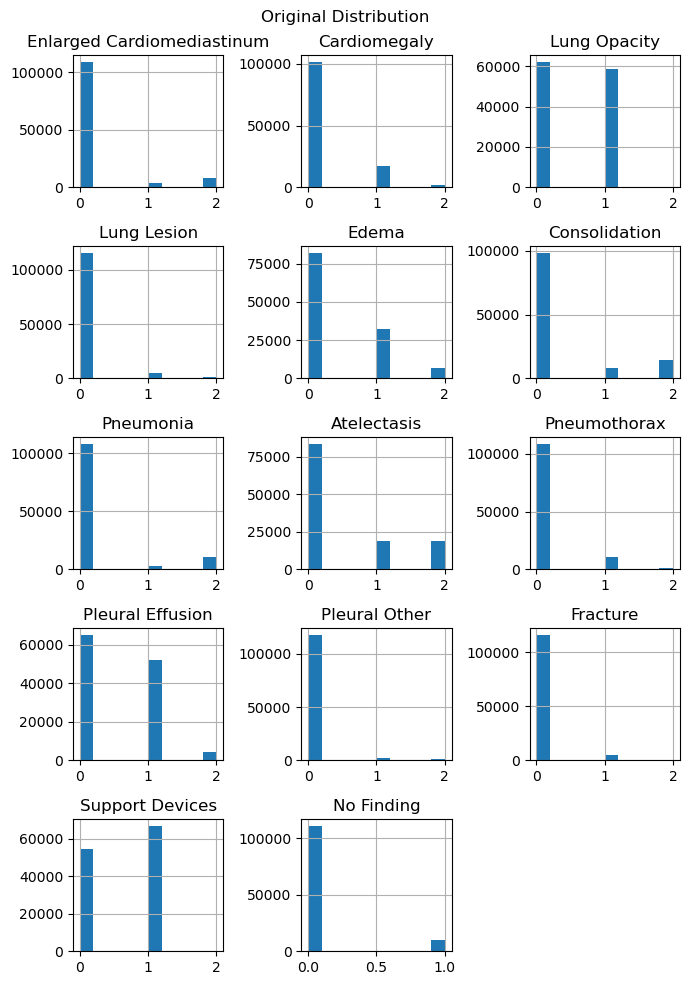

,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
count,121255.000000,121255.000000,121255.000000,121255.000000,121255.000000,121255.000000,121255.000000,121255.000000,121255.000000,121255.000000,121255.000000,121255.000000,121255.000000,121255.000000
mean,0.166715,0.177667,0.487535,0.050274,0.379292,0.308062,0.193122,0.462496,0.112837,0.496425,0.036955,0.041631,0.552027,0.082034
std,0.521819,0.426027,0.502414,0.246163,0.590800,0.674831,0.573154,0.746593,0.351183,0.563443,0.237915,0.209696,0.497918,0.274417
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000


In [11]:
### First visualize the original distributions
train_df2 = train_df.copy()

fig,axes = plt.subplots(5,3, figsize=(7,10))
for i,(col,ax) in enumerate(zip(class_cols, axes.flatten())):
    train_df2[col].hist(ax=ax)
    ax.set_title(col)

axes.flatten()[14].axis("off")
plt.suptitle("Original Distribution")
plt.tight_layout()
plt.show()

train_df2[class_cols].describe()

In [12]:
### Get class probabilities --> For each class, what is the probability of a non-zero value?

# Get the count of non-zero instances per class
col_sums = train_df[class_cols].map(lambda x: 1 if x==1 else 1 if x==2 else 0).sum(axis=0)

# Get the total count of ALL instances
df_sum = len(train_df)

# Get the fraction of non-zero instances for each class
class_probs = col_sums / df_sum

# Perform 1 / prob to amplify the smaller numbers and minimize the bigger numbers
class_probs = 1 / class_probs

# Adjust so that the probabilities add up to 1
class_probs = class_probs / class_probs.sum()

for freq in class_probs:
    print(freq)

class_probs

0.06608382755578038
0.041322407816882005
0.01359448345359668
0.15074868241942074
0.020497934798456904
0.035359570514560616
0.061903826415203915
0.021455397623643135
0.06530314033111131
0.014286771552752263
0.2499316321871095
0.1669507903403583
0.011981385757781403
0.08058014923334274


Enlarged Cardiomediastinum    0.066084
Cardiomegaly                  0.041322
Lung Opacity                  0.013594
Lung Lesion                   0.150749
Edema                         0.020498
Consolidation                 0.035360
Pneumonia                     0.061904
Atelectasis                   0.021455
Pneumothorax                  0.065303
Pleural Effusion              0.014287
Pleural Other                 0.249932
Fracture                      0.166951
Support Devices               0.011981
No Finding                    0.080580
dtype: float64

In [13]:
### Get class value probabilities

### Get the probability that one of the classes will be either (1) or (2)
# Find the count of each instance of 1 and 2 across ALL classes
counts = {}
for col in class_cols:
    for i in range(1,3,1):
        counts[i] = counts.get(i, 0) + train_df.loc[train_df[col]==i ,col].count()

# Find the total number of values across ALL classes
sum_counts = len(train_df) * len(class_cols)

# Find the fraction of all values that are either (1) or (2) --> This is the probability of occurrence
class_value_probs = np.array([counts[1]/sum_counts, counts[2]/sum_counts])

### Given these probabilities, create a probability distribution of selecting either 1 or 2 which boosts the counts of the underrepresented value
# Perform 1 / prob to amplify the smaller numbers and minimize the bigger numbers
class_value_probs = 1 / class_value_probs

# Adjust so that the probabilities add up to 1
class_value_probs = class_value_probs / np.sum(class_value_probs)

for prob in class_value_probs:
    print(prob)

class_value_probs

0.1910498186148265
0.8089501813851734


array([0.19104982, 0.80895018])

In [32]:
# Using class and value probabilties, get a resampled set with replacement, emphasizing underrepresented classes
n_samples = 30000

#####
n_classes = len(class_cols)
df = train_df.copy()

batch = []
# For each sample index, get the column and value to create a df subset
col_sample = np.random.choice(np.arange(n_classes),
                              size=n_samples,
                              replace=True,
                              p=class_probs)
# Probabilities here are the (1-freq) of each class value occuring in train_df
val_sample = np.random.choice([1,2],
                              size=n_samples,
                              replace=True,
                              p=class_value_probs)

for i,(col_samp, val_samp) in enumerate(zip(col_sample, val_sample)):
    # Cover edge case of no uncertain "No Finding"
    if col_samp == len(class_cols) - 1:
        val_samp = 1

    # print(col_samp, val_samp)
        
    # Retrieve a random instance where the specified column has the specified value
    subset_df = df[class_cols[col_samp]]
    subset_df = subset_df[subset_df == val_samp]
    if len(subset_df) == 1:
        batch.append(subset_df.index[0])
    else:
        batch.append(subset_df.sample(1).index[0])
            
batch[:10]

[56583, 86529, 67969, 5863, 49583, 117671, 119811, 21465, 26323, 64378]

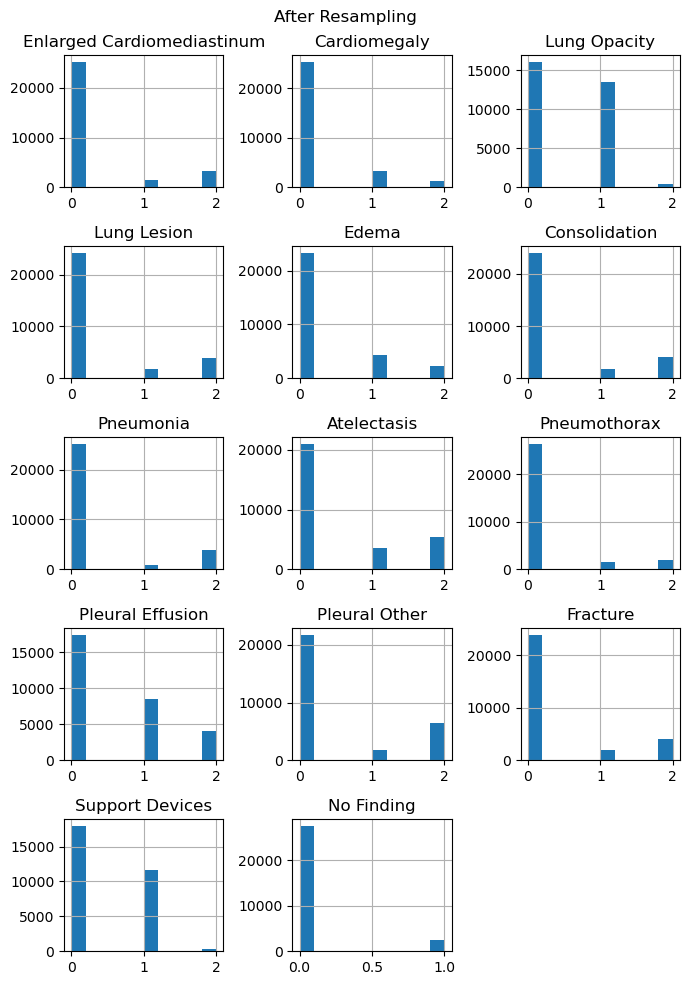

,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.265967,0.197367,0.475867,0.323267,0.296533,0.33240,0.290800,0.478133,0.180500,0.553733,0.488033,0.339600,0.410367,0.080800
std,0.642995,0.493242,0.525763,0.693672,0.598565,0.70166,0.684483,0.781287,0.523764,0.720183,0.822646,0.706886,0.512160,0.272532
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
max,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000


In [33]:
### Visualize the resampled set
train_df2 = train_df.loc[batch,:]

fig,axes = plt.subplots(5,3, figsize=(7,10))
for i,(col,ax) in enumerate(zip(class_cols, axes.flatten())):
    train_df2[col].hist(ax=ax)
    ax.set_title(col)

axes.flatten()[14].axis("off")
plt.suptitle("After Resampling")
plt.tight_layout()
plt.show()

train_df2[class_cols].describe()

In [34]:
print(f"# rows in train_df2: {len(train_df2)}")
print(f"# rows in train_df_full: {len(train_df_full)}")
print(f"# rows in valid_df: {len(valid_df)}")
print(f"# rows in test_df: {len(test_df)}")
print(f"# rows in valid_rad_df: {len(valid_rad_df)}")
print(f"# rows in test_rad_df: {len(test_rad_df)}")

# rows in train_df2: 30000
# rows in train_df_full: 151656
# rows in valid_df: 30401
# rows in test_df: 39371
# rows in valid_rad_df: 202
# rows in test_rad_df: 518


In [35]:
### Save new training, validation, test csvs
train_df2.to_csv(f"{root}train_df.csv", index=False)
train_df_full.to_csv(f"{root}train_df_full.csv", index=False)
#
valid_df.to_csv(f"{root}valid_df.csv", index=False)
test_df.to_csv(f"{root}test_df.csv", index=False)
#
valid_rad_df.to_csv(f"{root}valid_rad_df.csv", index=False)
test_rad_df.to_csv(f"{root}test_rad_df.csv", index=False)

In [36]:
### Save the class probabilities and class value probabilties
class_probs.to_csv(f"{root}/class_probs.txt", index=True, header=False)
np.savetxt(f"{root}/class_value_probs.txt", np.array(class_value_probs))